0. 필수 라이브러리 설치 및 시스템 설정

In [39]:
# 1. 필수 라이브러리 설치
!pip install transformers torch scikit-learn biopython pandas numpy matplotlib

# 2. 구글 드라이브 마운트
from google.colab import drive
import os
drive.mount('/content/drive', force_remount=True)

# 3. 작업 경로 설정
drive_path = '/content/drive/MyDrive/Peptide_Project'
if not os.path.exists(drive_path):
    os.makedirs(drive_path)
    print(f"✅ 경로 생성 완료: {drive_path}")

# 4. Hugging Face 인증 (Secrets에 HF_TOKEN을 등록했다면 자동 연동됩니다)
# 토큰은 TOKEN 파일에 있습니다.
try:
    from google.colab import userdata
    os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')
    print("✅ Hugging Face 토큰 인증 성공!")
except:
    print("⚠️ 경고: HF_TOKEN이 없습니다. 익명 모드로 진행하여 속도가 제한될 수 있습니다.")

Mounted at /content/drive
✅ Hugging Face 토큰 인증 성공!


1. User_input setting json 설정 (input 파트)

In [40]:
system_config = {
    "data_params": {
        "dataset_path": f"{drive_path}/peptide_dataset_5_50.csv",
        "sample_size": 20000,
        "max_len": 50
    },
    "weights": {
        "w_1_ai": 1.0,      # 최우선 목표: 면역 거부 반응 최소화
        "w_2_gravy": 0.5,   # 제약: 친소수성 안전지대 지정 (-0.4 ~ 0.4)
        "w_3_charge": 0.5,  # 제약: 전하량 안전지대 지정 (-1.0 ~ 1.0)
        "w_4_cd47": 0.4     # 전략: CD47의 면역 회피 모티프를 갖고 있을 시 보너스 부여
    },
    "algorithm_params": {
        "ga_generations": 30,
        "ga_pop_size": 100,
        "mutation_rate": 0.3, # Indel 변이 반영을 위해 높게 설정
        "n_runs_bench": 3     # Ablation Study 반복 횟수
    },
    "design_constraints": {
        "hCD47_reference": "EVTELT" # CD47의 면역 회피 모티프
    }
}

2. 데이터 로드 및 일괄 전처리 단계

In [41]:
import torch
import pandas as pd
import numpy as np
from transformers import EsmTokenizer
from Bio.Align import substitution_matrices
from torch.utils.data import TensorDataset, DataLoader

def prepare_data(config):
    print("📊 데이터 로딩 및 일괄 전처리 시작...")
    df = pd.read_csv(config["data_params"]["dataset_path"]).dropna(subset=['Sequence', 'Target'])
    if len(df) > config["data_params"]["sample_size"]:
        df = df.sample(n=config["data_params"]["sample_size"], random_state=42)

    sequences = df['Sequence'].tolist()
    labels = torch.tensor(df['Target'].values, dtype=torch.float32)

    # 1. BLOSUM62 Embedding
    # BLOSUM62 = 생물학적 관계도를 숫자로 바꾼 사전
    # BLOSUM62를 이용해서 아미노산 서열을 AI가 이해할 수 있도록 정리하는 과정

    blosum62 = substitution_matrices.load("BLOSUM62")
    aa_order = "ARNDCQEGHILKMFPSTWYV"
    aa_to_idx = {aa: i for i, aa in enumerate(aa_order)}

    max_len = config["data_params"]["max_len"]
    blosum_tensors = np.zeros((len(sequences), max_len, 20), dtype=np.float32)
    for idx, seq in enumerate(sequences):
        start_idx = max(0, max_len - len(seq))
        for i, aa in enumerate(seq[-max_len:]):
            if aa in aa_to_idx:
                for j, ref_aa in enumerate(aa_order):
                    blosum_tensors[idx, start_idx + i, j] = blosum62.get((aa, ref_aa), -1)

    # 2. ESM-2 Tokenization
    # ESM-2 = 이미 엄청난 양의 데이터를 학습한 모델
    # ESM-2에 바로 들어갈 수 있도록 데이터 전체를 미리 토큰화해서 작업 속도를 높인 과정

    tokenizer = EsmTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
    esm_encodings = tokenizer(sequences, padding='max_length', max_length=max_len+2, truncation=True, return_tensors="pt")

    print("✅ 데이터 변환 완료!")
    return TensorDataset(torch.tensor(blosum_tensors), esm_encodings['input_ids'], esm_encodings['attention_mask'], labels), aa_to_idx

dataset, aa_idx = prepare_data(system_config)

📊 데이터 로딩 및 일괄 전처리 시작...
✅ 데이터 변환 완료!


3. AI 모델들을 정의하는 단계 (pipeline A 시작부)

In [42]:
import torch.nn as nn
import torch.nn.functional as F
from transformers import EsmModel

# 모델1: 1D-CNN
class CNNOnly(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Conv1d(20, 64, kernel_size=3, padding=1)
        self.fc = nn.Linear(64, 1)
    def forward(self, blosum, ids, mask):
        x = F.relu(self.cnn(blosum.permute(0, 2, 1)))
        return torch.sigmoid(self.fc(F.max_pool1d(x, x.size(2)).squeeze(2)))

# 모델2: Bi-LSTM
class LSTMOnly(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(20, 64, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(128, 1)
    def forward(self, blosum, ids, mask):
        out, _ = self.lstm(blosum)
        return torch.sigmoid(self.fc(out[:, -1, :]))

# 모델3: 직렬 형식의 hybrid model
# 1D-CNN -> Max-Pooling -> Bi-LSTM으로 연결된 model로, 프로젝트에서 메인이 되는 모델
# 1D-CNN: 독성이 있는 부위를 뽑아내는 역할
# Bi-LSTM: 맥락을 읽고 판단하는 역할
class SeqHybrid(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Conv1d(20, 64, kernel_size=3, padding=1)
        self.lstm = nn.LSTM(64, 64, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(128, 1)
    def forward(self, blosum, ids, mask):
        x = F.relu(self.cnn(blosum.permute(0, 2, 1)))
        out, _ = self.lstm(F.max_pool1d(x, 2).permute(0, 2, 1))
        return torch.sigmoid(self.fc(out[:, -1, :]))

# 모델4: 병렬 형식의 hybrid model
# 직렬로 해야하는 이유를 보여주기 위함
# 데이터가 두 모델에 각각 들어가서 나온 feature들을 late fusion으로 결합하는 방식
class ParallelHybrid(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Conv1d(20, 64, kernel_size=3, padding=1)
        self.lstm = nn.LSTM(20, 64, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(64 + 128, 1)
    def forward(self, blosum, ids, mask):
        x_c = F.max_pool1d(F.relu(self.cnn(blosum.permute(0, 2, 1))), 50).squeeze(2)
        out, _ = self.lstm(blosum)
        return torch.sigmoid(self.fc(torch.cat((x_c, out[:, -1, :]), dim=1)))

# 모델5: ESM-2
# 기존에 이미 많은 데이터를 학습한 모델로 하면 되는 거 아닌가를 확인하기 위함.
class ESM2Only(nn.Module):
    def __init__(self):
        super().__init__()
        self.esm2 = EsmModel.from_pretrained("facebook/esm2_t6_8M_UR50D")
        for p in self.esm2.parameters(): p.requires_grad = False
        self.fc = nn.Linear(320, 1)
    def forward(self, blosum, ids, mask):
        out = self.esm2(input_ids=ids, attention_mask=mask)
        return torch.sigmoid(self.fc(out.last_hidden_state[:, 0, :]))

# 모델6: main(seq hybrid) + auxiliary(ESM-2)
# 메인 모델에 ESM-2를 통한 보조를 통해 결과가 더 좋아질 수 있는지 확인하기 위함.
class MainAuxHybrid(nn.Module):
    def __init__(self):
        super().__init__()
        self.main_cnn = nn.Conv1d(20, 32, kernel_size=3, padding=1)
        self.main_lstm = nn.LSTM(32, 32, batch_first=True, bidirectional=True)
        self.esm2 = EsmModel.from_pretrained("facebook/esm2_t6_8M_UR50D")
        for p in self.esm2.parameters(): p.requires_grad = False
        self.fc = nn.Linear(64 + 320, 1)
    def forward(self, blosum, ids, mask):
        x_m = F.max_pool1d(F.relu(self.main_cnn(blosum.permute(0, 2, 1))), 2).permute(0, 2, 1)
        out, _ = self.main_lstm(x_m)
        esm_out = self.esm2(input_ids=ids, attention_mask=mask)
        return torch.sigmoid(self.fc(torch.cat((out[:, -1, :], esm_out.last_hidden_state[:, 0, :]), dim=1)))

# max-pooling의 여부에 따른 성능의 차이를 비교하기 위한 모델들

# 모델7: max-pooling이 없는 직렬 형식의 hybrid 모델
class SeqHybridNoPool(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Conv1d(20, 64, kernel_size=3, padding=1)
        self.lstm = nn.LSTM(64, 64, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(128, 1)
    def forward(self, blosum, ids, mask):
        x = F.relu(self.cnn(blosum.permute(0, 2, 1)))
        # Max Pooling 제거: CNN의 출력을 바로 모양만 바꿔서(길이 유지) LSTM에 전달!
        out, _ = self.lstm(x.permute(0, 2, 1))
        return torch.sigmoid(self.fc(out[:, -1, :]))

#모델8: max-pooling이 없는 병렬 형식의 seq hybrid 모델
class ParallelHybridNoPool(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Conv1d(20, 64, kernel_size=3, padding=1)
        self.lstm = nn.LSTM(20, 64, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(64 + 128, 1)
    def forward(self, blosum, ids, mask):
        x = F.relu(self.cnn(blosum.permute(0, 2, 1)))
        # Max Pooling 제거: CNN 전체 출력의 평균을 내서(Global Average) 정보를 보존해봄
        x_c = torch.mean(x, dim=2)
        out, _ = self.lstm(blosum)
        return torch.sigmoid(self.fc(torch.cat((x_c, out[:, -1, :]), dim=1)))

'''
모델 1~8을 비교한 결과, ESM-2를 적용하는 부분은 역효과를 냈으며, max-pooling 또한 결과에 좋은 영향을 주지 못했음.

1D-CNN 단독 모델과 병렬 형식의 모델은 성능이 좋지 않았음.

다만, Bi-LSTM의 성능이 seq hybrid 보다 좋은 결과를 도출한 것을 통해 seq hybrid에 문제가 있음을 확인함.

문제는 Cascading Errors로 확인됐으며, 아래의 보완 방식을 각각 적용하여 보완해보기로 함.

1. Residual Connection / Skip Connection
2. Attention Mechanism

'''

# 🔥 1. 잔차 연결 (Residual Connection) 적용 모델 🔥
class SeqHybridResidual(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Conv1d(20, 64, kernel_size=3, padding=1)
        # 원본(20) + CNN요약본(64) = 84 차원의 데이터를 LSTM이 받음
        self.lstm = nn.LSTM(84, 64, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(128, 1)

    def forward(self, blosum, ids, mask):
        x_cnn = F.relu(self.cnn(blosum.permute(0, 2, 1))) # (B, 64, L)
        # 지름길: CNN 요약본과 원본 블로섬 데이터를 결합 (Concat)
        x_combined = torch.cat((blosum.permute(0, 2, 1), x_cnn), dim=1) # (B, 84, L)
        out, _ = self.lstm(x_combined.permute(0, 2, 1))
        return torch.sigmoid(self.fc(out[:, -1, :]))

# 🔥 2. 어텐션 매커니즘 (Attention Mechanism) 적용 모델 🔥
class SeqHybridAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Conv1d(20, 64, kernel_size=3, padding=1)
        self.lstm = nn.LSTM(64, 64, batch_first=True, bidirectional=True)
        # 각 아미노산 위치에 매길 가중치(형광펜)를 학습하는 층
        self.attention = nn.Linear(128, 1)
        self.fc = nn.Linear(128, 1)

    def forward(self, blosum, ids, mask):
        x = F.relu(self.cnn(blosum.permute(0, 2, 1)))
        out, _ = self.lstm(x.permute(0, 2, 1)) # out shape: (B, L, 128)

        # 어텐션 스코어 계산 (어떤 아미노산이 중요한가?)
        attn_weights = F.softmax(self.attention(out), dim=1) # shape: (B, L, 1)

        # 중요도에 따라 전체 문맥 벡터를 하나로 응축 (Weighted Sum)
        context_vector = torch.sum(attn_weights * out, dim=1) # shape: (B, 128)
        return torch.sigmoid(self.fc(context_vector))

4. 모델간 비교 실험 (Ablation study) 및 체크포인트 저장

---
1. 각 모델은 동일한 epoch(30)로 학습
2. 시행은 총 3번 진행하며, 3회의 결과값의 평균값을 구하여 모델 간 비교한다.
3. 결과값은 각 시행마다 Validation Loss가 가장 낮았던 최적의 Epoch의 값으로 한다.
4. 결과값으로 사용하는 것은 'AUROC의 평균과 표준편차', '평균 학습시간', 'peak memory usage'이다.


In [43]:
import time
import tracemalloc
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score

# 🔥 누락된 device 설정 추가! 🔥
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ 현재 사용 중인 디바이스: {device}")

# -------------------------------------------------------------------
# 트래킹용 전역 딕셔너리 생성
# -------------------------------------------------------------------
# 구조: history[model_name] = {'auroc_history': [[epoch1...15], [epoch1...15], [epoch1...15]], 'times': [], 'memories': []}
model_history = {}

def run_benchmarking_v_final(dataset, config):
    models = {
        # 단독 모델 (비교군)
        "1D-CNN Only": CNNOnly,
        "Bi-LSTM Only": LSTMOnly,
        # 직렬 연결 방식의 모델 (목표 모델), max-pooling 포함/미포함
        "Seq Hybrid (Pool)": SeqHybrid,
        "Seq Hybrid (No Pool)": SeqHybridNoPool,
        # 병렬 연결 방식의 모델 (비교군), max-pooling 포함/미포함
        "Parallel Hybrid (Pool)": ParallelHybrid,
        "Parallel Hybrid (No Pool)": ParallelHybridNoPool,
        # ESM-2를 접목한 모델 (test용 모델)
        "ESM-2 Only": ESM2Only,
        "Main-Aux Hybrid": MainAuxHybrid,
        # 🌟 새롭게 참전하는 완전체 모델 2종 🌟
        "Seq Hybrid (Residual)": SeqHybridResidual,
        "Seq Hybrid (Attention)": SeqHybridAttention,
    }

    results = []
    print(f"\n🚀 {config['algorithm_params']['n_runs_bench']}-Run Benchmarking Started...\n")

    for name, model_class in models.items():
        print(f"▶ Training [{name}]...")
        model_history[name] = {'auroc_history': [], 'times': [], 'memories': [], 'best_epochs': []}

        run_aurocs = []

        for run in range(config["algorithm_params"]["n_runs_bench"]):
            torch.manual_seed(run)
            model = model_class().to(device)
            optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

            train_set, val_set = torch.utils.data.random_split(dataset, [16000, len(dataset)-16000])
            train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
            val_loader = DataLoader(val_set, batch_size=128)

            best_val_loss = float('inf')
            save_path = f"{drive_path}/best_{name.replace(' ', '_')}.pth"

            # --- 트래킹 변수 ---
            run_epoch_aurocs = []
            best_ep = 0

            tracemalloc.start()
            start_time = time.time()

            # Epoch 루프
            for epoch in range(30):
                model.train()
                for b, i, m, l in train_loader:
                    optimizer.zero_grad()
                    loss = F.binary_cross_entropy(model(b.to(device), i.to(device), m.to(device)).squeeze(), l.to(device))
                    loss.backward()
                    optimizer.step()

                model.eval()
                v_loss = 0
                all_p, all_l = [], []
                with torch.no_grad():
                    for b, i, m, l in val_loader:
                        preds = model(b.to(device), i.to(device), m.to(device)).squeeze()
                        v_loss += F.binary_cross_entropy(preds, l.to(device)).item()
                        all_p.extend(preds.cpu().numpy())
                        all_l.extend(l.numpy())

                # Checkpointing
                if v_loss < best_val_loss:
                    best_val_loss = v_loss
                    best_ep = epoch + 1
                    torch.save(model.state_dict(), save_path)

                # 매 에포크마다 AUROC 기록 (그래프용)
                run_epoch_aurocs.append(roc_auc_score(all_l, all_p))

            # 기록 저장
            run_time = time.time() - start_time
            _, peak_mem = tracemalloc.get_traced_memory()
            tracemalloc.stop()

            model_history[name]['auroc_history'].append(run_epoch_aurocs)
            model_history[name]['times'].append(run_time)
            model_history[name]['memories'].append(peak_mem / 10**6) # MB 변환
            model_history[name]['best_epochs'].append(best_ep)

            # 런 최종 성능은 황금기(Checkpoint) 모델 로드하여 산출
            model.load_state_dict(torch.load(save_path))
            model.eval()
            all_p_final, all_l_final = [], []
            with torch.no_grad():
                for b, i, m, l in val_loader:
                    all_p_final.extend(model(b.to(device), i.to(device), m.to(device)).squeeze().cpu().numpy())
                    all_l_final.extend(l.numpy())
            run_aurocs.append(roc_auc_score(all_l_final, all_p_final))

        # N-Run 통계 수합
        avg_auroc = np.mean(run_aurocs)
        std_auroc = np.std(run_aurocs)
        avg_time = np.mean(model_history[name]['times'])

        results.append({
            "Model": name,
            "Mean_AUROC": avg_auroc,
            "Std_AUROC": std_auroc,
            "Mean_Time": avg_time,
            "Peak_Mem_MB": np.mean(model_history[name]['memories'])
        })

    return pd.DataFrame(results)

df_report = run_benchmarking_v_final(dataset, system_config)
print(df_report)

🖥️ 현재 사용 중인 디바이스: cuda

🚀 3-Run Benchmarking Started...

▶ Training [1D-CNN Only]...
▶ Training [Bi-LSTM Only]...
▶ Training [Seq Hybrid (Pool)]...
▶ Training [Seq Hybrid (No Pool)]...
▶ Training [Parallel Hybrid (Pool)]...
▶ Training [Parallel Hybrid (No Pool)]...
▶ Training [ESM-2 Only]...


Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


▶ Training [Seq Hybrid (Residual)]...
▶ Training [Seq Hybrid (Attention)]...
                       Model  Mean_AUROC  Std_AUROC   Mean_Time  Peak_Mem_MB
0                1D-CNN Only    0.618429   0.009691   41.790294    65.296875
1               Bi-LSTM Only    0.735761   0.005083   48.407836     1.157610
2          Seq Hybrid (Pool)    0.728045   0.012978   47.002943     1.156413
3       Seq Hybrid (No Pool)    0.732283   0.013073   46.296894     1.156870
4     Parallel Hybrid (Pool)    0.721079   0.010644   47.284129     1.156309
5  Parallel Hybrid (No Pool)    0.728082   0.008966   46.908110     1.156568
6                 ESM-2 Only    0.656952   0.003231  288.133751     1.470627
7            Main-Aux Hybrid    0.728096   0.004327  294.416073     1.475789
8      Seq Hybrid (Residual)    0.708696   0.009720   46.844505     1.158989
9     Seq Hybrid (Attention)    0.709190   0.005037   48.918867     1.155360


5. 비교 실험 결과 시각화 (차이가 큰 부분이 있어 일부 구간 생략)

✅ 그래프가 구글 드라이브에 저장되었습니다: /content/drive/MyDrive/Peptide_Project/benchmark_results_grouped_final.png


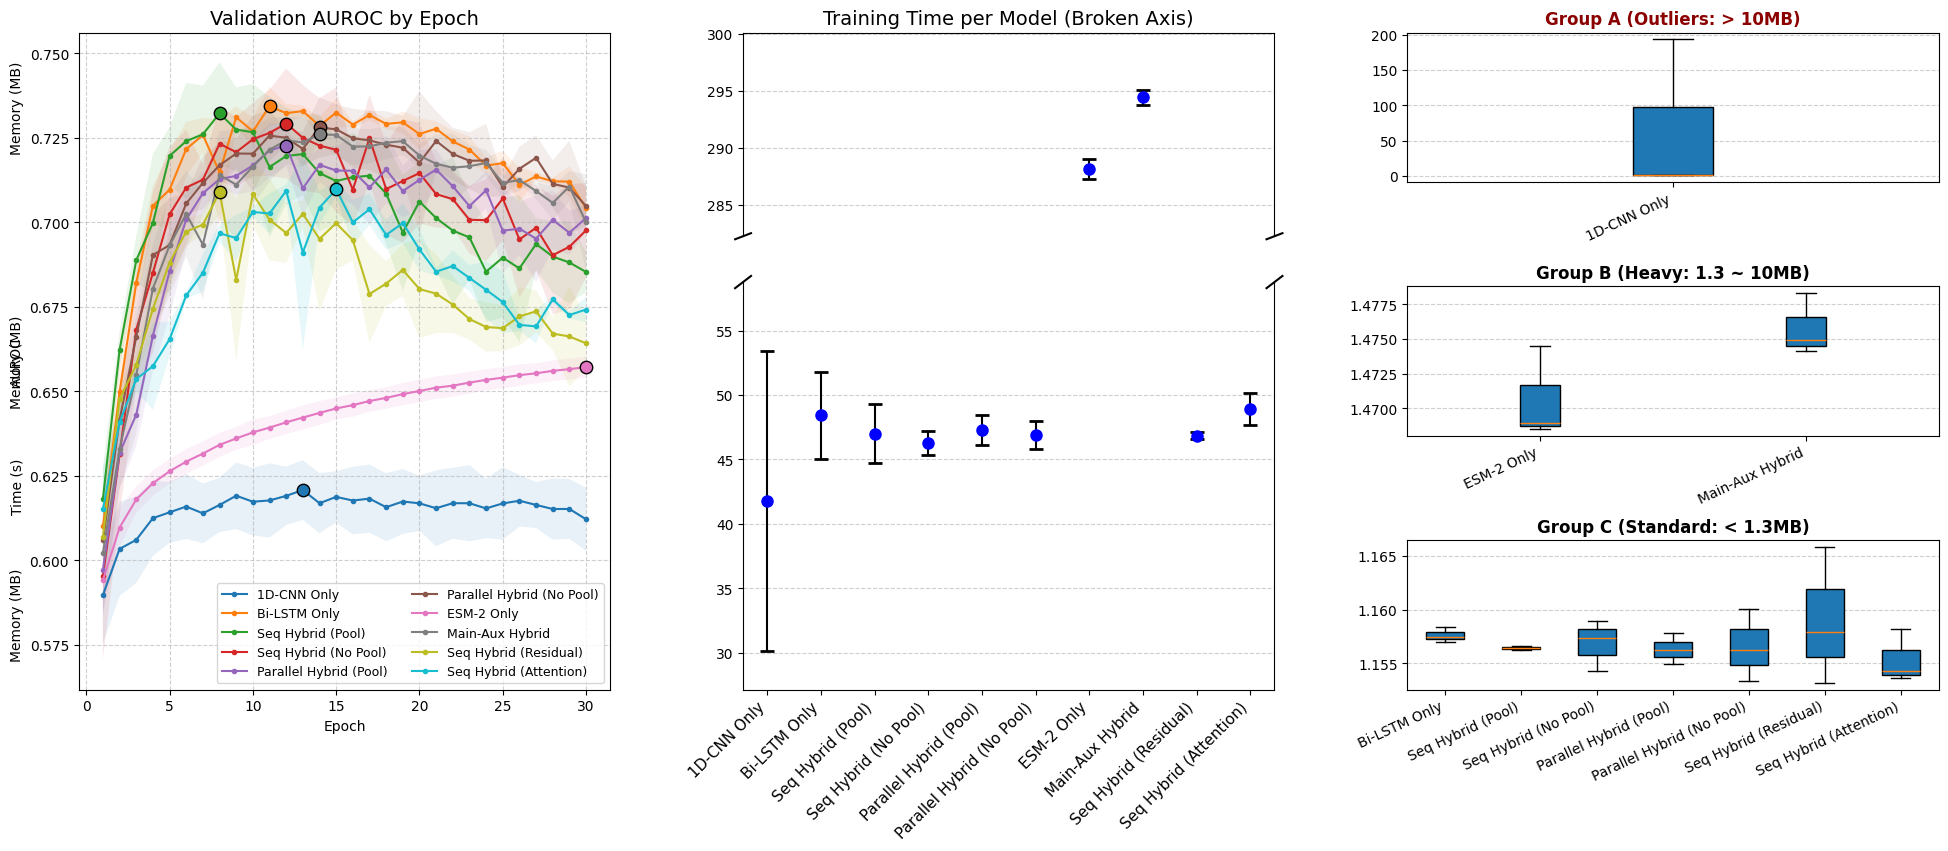

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import os

def plot_benchmark_results_grouped(history_dict, df):
    # 우측 메모리 그래프가 3층으로 쌓일 것을 대비해 세로 길이를 9로 충분히 늘려줍니다.
    fig = plt.figure(figsize=(24, 9))

    # 1행 3열의 큰 뼈대 생성
    gs0 = gridspec.GridSpec(1, 3, figure=fig, wspace=0.25, bottom=0.15)

    models = list(history_dict.keys())

    # -------------------------------------------------------------
    # 1. AUROC per Epoch Graph (좌측 - 건드리지 않음)
    # -------------------------------------------------------------
    ax1 = fig.add_subplot(gs0[0])
    for model_name in models:
        hist_array = np.array(history_dict[model_name]['auroc_history'])
        mean_auroc = np.mean(hist_array, axis=0)
        std_auroc = np.std(hist_array, axis=0)

        epochs = np.arange(1, len(mean_auroc) + 1)

        line, = ax1.plot(epochs, mean_auroc, label=model_name, marker='o', markersize=3)
        ax1.fill_between(epochs, mean_auroc - std_auroc, mean_auroc + std_auroc, alpha=0.1)

        best_ep = np.argmax(mean_auroc)
        ax1.scatter(epochs[best_ep], mean_auroc[best_ep], color=line.get_color(), s=80, edgecolors='black', zorder=5)

    ax1.set_title("Validation AUROC by Epoch", fontsize=14)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("AUROC")
    ax1.legend(fontsize=9, loc='lower right', ncol=2)
    ax1.grid(True, linestyle='--', alpha=0.6)

    # -------------------------------------------------------------
    # 2. Training Time Plot (가운데 - 건드리지 않음)
    # -------------------------------------------------------------
    gs_time = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs0[1], height_ratios=[1, 2], hspace=0.15)
    ax2_top = fig.add_subplot(gs_time[0])
    ax2_bot = fig.add_subplot(gs_time[1], sharex=ax2_top)

    means = df['Mean_Time'].values
    stds = [np.std(history_dict[m]['times']) for m in models]

    low_vals = [m+s for m, s in zip(means, stds) if m < 100] + [m-s for m, s in zip(means, stds) if m < 100]
    high_vals = [m+s for m, s in zip(means, stds) if m >= 100] + [m-s for m, s in zip(means, stds) if m >= 100]

    x_pos = np.arange(len(models))
    ax2_top.errorbar(x_pos, means, yerr=stds, fmt='o', capsize=5, capthick=2, ecolor='black', color='blue', markersize=8)
    ax2_bot.errorbar(x_pos, means, yerr=stds, fmt='o', capsize=5, capthick=2, ecolor='black', color='blue', markersize=8)

    ax2_bot.set_ylim(max(0, min(low_vals) * 0.9), max(low_vals) * 1.1)
    ax2_top.set_ylim(min(high_vals) - 5, max(high_vals) + 5)
    ax2_top.yaxis.set_major_locator(ticker.MultipleLocator(5))

    ax2_top.spines['bottom'].set_visible(False)
    ax2_bot.spines['top'].set_visible(False)
    ax2_top.tick_params(labelbottom=False, bottom=False)

    d = .015
    kwargs = dict(transform=ax2_top.transAxes, color='k', clip_on=False)
    ax2_top.plot((-d, +d), (-d, +d), **kwargs); ax2_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)
    kwargs.update(transform=ax2_bot.transAxes)
    ax2_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs); ax2_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

    ax2_top.set_title("Training Time per Model (Broken Axis)", fontsize=14)
    ax2_bot.set_ylabel("Time (s)")
    ax2_bot.set_xticks(x_pos)
    ax2_bot.set_xticklabels(models, rotation=45, ha='right', fontsize=11)
    ax2_top.grid(axis='y', linestyle='--', alpha=0.6)
    ax2_bot.grid(axis='y', linestyle='--', alpha=0.6)

    # -------------------------------------------------------------
    # 3. Peak Memory Box Plot (🌟 유저 요청: 스케일별 독립 그룹핑 🌟)
    # -------------------------------------------------------------
    mem_means = [np.mean(history_dict[m]['memories']) for m in models]

    # 모델들을 메모리 사용량에 따라 3개의 방(Group)으로 자동 분류합니다.
    groups = {
        'Group A (Outliers: > 10MB)': [],
        'Group B (Heavy: 1.3 ~ 10MB)': [],
        'Group C (Standard: < 1.3MB)': []
    }

    for m, val in zip(models, mem_means):
        if val > 10:
            groups['Group A (Outliers: > 10MB)'].append(m)
        elif val > 1.3:
            groups['Group B (Heavy: 1.3 ~ 10MB)'].append(m)
        else:
            groups['Group C (Standard: < 1.3MB)'].append(m)

    # 데이터가 존재하는 방(Group)만 남깁니다.
    active_groups = {k: v for k, v in groups.items() if len(v) > 0}
    num_groups = len(active_groups)

    # 우측 기둥(gs0[2])을 활성화된 그룹의 개수만큼 세로로 쪼갭니다.
    gs_mem = gridspec.GridSpecFromSubplotSpec(num_groups, 1, subplot_spec=gs0[2], hspace=0.7)

    for i, (g_name, g_models) in enumerate(active_groups.items()):
        ax3 = fig.add_subplot(gs_mem[i])
        g_data = [history_dict[m]['memories'] for m in g_models]

        # 선형 스케일(Linear Scale)로 박스플롯 렌더링
        ax3.boxplot(g_data, patch_artist=True)
        ax3.set_title(g_name, fontsize=12, fontweight='bold', color='darkred' if i==0 else 'black')
        ax3.set_ylabel("Memory (MB)")

        # X축 라벨 세팅 (각 방에 들어있는 모델 이름만 출력)
        ax3.set_xticks(range(1, len(g_models) + 1))
        ax3.set_xticklabels(g_models, rotation=25, ha='right', fontsize=10)
        ax3.grid(axis='y', linestyle='--', alpha=0.6)

    fig.align_labels()

    try:
        save_path = f"{drive_path}/benchmark_results_grouped_final.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ 그래프가 구글 드라이브에 저장되었습니다: {save_path}")
    except:
        pass

    plt.show()

# 함수 실행
plot_benchmark_results_grouped(model_history, df_report)

6. 최적 모델 선정 (pipeline A 종료부)


---
선정 기준
1. 최적 epoch에서의 AUROC의 값이 높을 것
2. 학습에 걸린 시간과 메모리 사용량이 작고 편차가 적을 것


In [52]:
print("🔍 Analyzing Benchmark Results using Multi-Objective Optimization...")

# 1. 스케일링을 위한 가중치(Penalty Weights) 설정
# (시간은 1초당 0.001점 감점, 메모리는 1MB당 0.05점 감점, 편차는 2배 감점)
W_STD = 2.0
W_TIME = 0.001
W_MEM = 0.05

# 2. 통합 점수(Total Score) 산출
df_report['Total_Score'] = (
    df_report['Mean_AUROC']
    - (W_STD * df_report['Std_AUROC'])
    - (W_TIME * df_report['Mean_Time'])
    - (W_MEM * df_report['Peak_Mem_MB'])
)

# 3. 1등 모델 판별
df_sorted = df_report.sort_values(by='Total_Score', ascending=False)
best_model_row = df_sorted.iloc[0]
best_model_name = best_model_row['Model']

print(f"\n🏆 최종 최적 모델 (Best Model Selected): [{best_model_name}]")
print(f"  - 통합 점수 (Total Score): {best_model_row['Total_Score']:.4f}")
print(f"  - 성능 지표 (AUROC) : {best_model_row['Mean_AUROC']:.4f} (±{best_model_row['Std_AUROC']:.4f})")
print(f"  - 연산 비용 (Time)  : {best_model_row['Mean_Time']:.1f} sec")
print(f"  - 메모리 (Memory)   : {best_model_row['Peak_Mem_MB']:.2f} MB\n")

# 전체 순위표 출력
print("📊 [모델별 최종 통합 점수 순위]")
print(df_sorted[['Model', 'Total_Score', 'Mean_AUROC', 'Mean_Time', 'Peak_Mem_MB']].to_string(index=False))

# 선택된 모델 클래스 인스턴스화 및 저장된 가중치 로드
model_mapping = {
    "1D-CNN Only": CNNOnly, "Bi-LSTM Only": LSTMOnly, "Seq Hybrid": SeqHybrid,
    "Parallel Hybrid": ParallelHybrid, "ESM-2 Only": ESM2Only, "Main-Aux Hybrid": MainAuxHybrid
}

best_model = model_mapping[best_model_name]().to(device)
best_model.load_state_dict(torch.load(f"{drive_path}/best_{best_model_name.replace(' ', '_')}.pth"))
best_model.eval()

print("\n✅ 파이프라인 B(유전 알고리즘)를 위한 최적 모델 가중치 로드 완료.")

🔍 Analyzing Benchmark Results using Multi-Objective Optimization...

🏆 최종 최적 모델 (Best Model Selected): [Bi-LSTM Only]
  - 통합 점수 (Total Score): 0.6193
  - 성능 지표 (AUROC) : 0.7358 (±0.0051)
  - 연산 비용 (Time)  : 48.4 sec
  - 메모리 (Memory)   : 1.16 MB

📊 [모델별 최종 통합 점수 순위]
                    Model  Total_Score  Mean_AUROC  Mean_Time  Peak_Mem_MB
             Bi-LSTM Only     0.619305    0.735761  48.407836     1.157610
Parallel Hybrid (No Pool)     0.605414    0.728082  46.908110     1.156568
     Seq Hybrid (No Pool)     0.601996    0.732283  46.296894     1.156870
        Seq Hybrid (Pool)     0.597265    0.728045  47.002943     1.156413
   Parallel Hybrid (Pool)     0.594692    0.721079  47.284129     1.156309
   Seq Hybrid (Attention)     0.592429    0.709190  48.918867     1.155360
    Seq Hybrid (Residual)     0.584461    0.708696  46.844505     1.158989
          Main-Aux Hybrid     0.351237    0.728096 294.416073     1.475789
               ESM-2 Only     0.288825    0.656952 288.1337

7. 유전 알고리즘을 통한 역설계 (Pipeline B)

---
유전 알고리즘 방식
1. 무작위로 100개의 펩타이드 서열을 만든다.
2. 최적 모델이 점수를 매겨 가장 안전하고 물성이 좋은 상위 20%만 남긴다.
3. 남은 것들끼리 일부를 교차하거나, 서열의 일부 길이가 늘어나거나 줄어드는 돌연변이가 발생한다.
4. 위 과정을 30~50세대 반복하여 결과물을 도출한다.

In [46]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio import Align

def calculate_fitness(seq, model, aa_to_idx, config):
    # 1. 생물학적 물성 평가
    pa = ProteinAnalysis(seq)
    gravy = pa.gravy()
    charge = pa.charge_at_pH(7.4)

    w = config["weights"]

    # 안전지대 페널티
    gravy_pen = 0 if -0.4 <= gravy <= 0.4 else min(abs(-0.4-gravy), abs(0.4-gravy))
    charge_pen = 0 if -1.0 <= charge <= 1.0 else min(abs(-1.0-charge), abs(1.0-charge))

    # 2. 모티프 상동성 평가 (Smith-Waterman)
    aligner = Align.PairwiseAligner()
    aligner.mode = 'local'
    motif_score = aligner.score(seq, config["design_constraints"]["hCD47_reference"])

    # 3. AI 모델 예측 (염증 확률)
    # 실제로는 Batch 처리가 좋지만, 여기서는 단일 평가
    max_len = config["data_params"]["max_len"]
    blosum_tensor = np.zeros((1, max_len, 20), dtype=np.float32)
    start_idx = max(0, max_len - len(seq))
    for i, aa in enumerate(seq[-max_len:]):
        if aa in aa_idx:
            blosum_tensor[0, start_idx + i, aa_idx[aa]] = 1.0 # 간이 임베딩

    b_t = torch.tensor(blosum_tensor).to(device)
    # ESM 토큰화는 가벼운 모델이 선택되었으므로 더미 처리(선택된 모델이 안 씀)
    dummy_ids = torch.zeros((1, max_len+2), dtype=torch.long).to(device)

    with torch.no_grad():
        p_fbr = model(b_t, dummy_ids, dummy_ids).item()

    # 최종 Cost (낮을수록 좋음)
    cost = (w["w_1_ai"] * p_fbr) + (w["w_2_gravy"] * gravy_pen) + (w["w_3_charge"] * charge_pen) - (w["w_4_cd47"] * (motif_score/6.0))
    return cost, p_fbr, gravy, charge, motif_score

def run_pipeline_B(model, aa_to_idx, config):
    pop_size = config["algorithm_params"]["ga_pop_size"]
    generations = config["algorithm_params"]["ga_generations"]
    mut_rate = config["algorithm_params"]["mutation_rate"]

    # 초기 집단 생성
    population = ["".join(np.random.choice(list("ARNDCQEGHILKMFPSTWYV"), np.random.randint(20, 50))) for _ in range(pop_size)]

    for gen in range(generations):
        # 적합도 평가
        scored_pop = [(calculate_fitness(seq, model, aa_to_idx, config), seq) for seq in population]
        scored_pop.sort(key=lambda x: x[0][0]) # Cost 오름차순 (낮은게 1등)

        # Elitism (상위 20% 보존)
        next_gen = [x[1] for x in scored_pop[:int(pop_size*0.2)]]

        # 교차 및 돌연변이
        while len(next_gen) < pop_size:
            p1, p2 = random.choice(next_gen[:10]), random.choice(next_gen[:10])
            split = min(len(p1), len(p2)) // 2
            child = p1[:split] + p2[split:]

            # Indel Mutation
            if random.random() < mut_rate:
                mut_type = random.choice(['sub', 'ins', 'del'])
                idx = random.randint(0, len(child)-1)
                if mut_type == 'sub': child = child[:idx] + random.choice(list("ARNDCEQGHILKMFPSTWYV")) + child[idx+1:]
                elif mut_type == 'ins' and len(child) < 50: child = child[:idx] + random.choice(list("ARNDCEQGHILKMFPSTWYV")) + child[idx:]
                elif mut_type == 'del' and len(child) > 5: child = child[:idx] + child[idx+1:]

            next_gen.append(child)
        population = next_gen

    final_scored = [(calculate_fitness(seq, model, aa_to_idx, config), seq) for seq in population]
    final_scored.sort(key=lambda x: x[0][0])
    return final_scored[0] # 최고 서열 반환

8. 민감도 분석

In [47]:
import copy
import random

print("\n🧬 [Phase 3] Dynamic Sensitivity Analysis Started...")

def execute_sensitivity_test(model, aa_to_idx, base_config):
    scenarios = {
        "Baseline (Balanced)": {"w_1_ai": 1.0, "w_2_gravy": 0.5, "w_3_charge": 0.5, "w_4_cd47": 0.4},
        "Scenario A (Only Immune)": {"w_1_ai": 3.0, "w_2_gravy": 0.1, "w_3_charge": 0.1, "w_4_cd47": 0.1},
        "Scenario B (Only Physio)": {"w_1_ai": 0.2, "w_2_gravy": 3.0, "w_3_charge": 3.0, "w_4_cd47": 0.1},
        "Scenario C (Motif Obsession)": {"w_1_ai": 0.2, "w_2_gravy": 0.1, "w_3_charge": 0.1, "w_4_cd47": 3.0}
    }

    res_list = []
    model.eval()

    for s_name, weights in scenarios.items():
        print(f"▶ Testing: [{s_name}]")
        temp_config = copy.deepcopy(base_config)
        temp_config["weights"] = weights
        temp_config["algorithm_params"]["ga_generations"] = 15 # 빠른 분석

        best_tuple, best_seq = run_pipeline_B(model, aa_to_idx, temp_config)
        cost, p_fbr, gravy, charge, motif = best_tuple

        res_list.append({
            "Scenario": s_name,
            "P_FBR": f"{p_fbr*100:.1f}%",
            "GRAVY": round(gravy, 2),
            "Charge": round(charge, 2),
            "Motif Score": round(motif, 2),
            "Top Sequence": best_seq,
            "Cost": round(cost, 3)
        })

    return pd.DataFrame(res_list)

df_sensitivity = execute_sensitivity_test(best_model, aa_idx, system_config)

print("\n" + "="*85)
print("🏆 [Final Report] Sensitivity Analysis Results")
print("="*85)
print(df_sensitivity.to_string(index=False))
print("="*85)


🧬 [Phase 3] Dynamic Sensitivity Analysis Started...
▶ Testing: [Baseline (Balanced)]
▶ Testing: [Scenario A (Only Immune)]
▶ Testing: [Scenario B (Only Physio)]
▶ Testing: [Scenario C (Motif Obsession)]

🏆 [Final Report] Sensitivity Analysis Results
                    Scenario P_FBR  GRAVY  Charge  Motif Score                                 Top Sequence   Cost
         Baseline (Balanced) 58.5%  -0.06    0.57          3.0                   CEVHWVTWFGAYDCHFNKMKKFMINF  0.385
    Scenario A (Only Immune) 58.3%   0.15    0.52          2.0       CQFVVWIRDITNWKWYIVAAPPSLQWKMDVEVYIKMNM  1.717
    Scenario B (Only Physio) 58.2%  -0.03    0.48          4.0 VSKNYQAEWTNLTIQWGVIKKGISEYAANCWQMYVGMYGYGIIM  0.050
Scenario C (Motif Obsession) 58.7%  -0.14   -0.50          5.0                VEVMELTQYGGMSISPTHACKCGYYYKIQ -2.383
